In [7]:
import scipy as sp
#from scipy.misc import derivative
from scipy.special import jv, hankel2, hankel1, yv, jvp, yvp, factorial
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, pi, exp, conj, argmin, unravel_index, log, einsum, tan, log10, atan, cosh
import torch
import warnings
warnings.filterwarnings("ignore")
from utils import h_z_cpa, h_z_cpa_denominator, h_z_cpa_numerator, e_z_cpa, e_z_cpa_numerator, hl2_prime, hl1_prime, hbar, c, alpha, graphene_conductivity

### This notebook reproduces select figures from the following paper: [Spaser and optical amplification conditions in graphene-coated active wires](https://opg.optica.org/josab/fulltext.cfm?uri=josab-38-7-2118), published in 2021 in JOSA B.

### Figure 1 displays the resonant frequencies as $\omega/c$ in units of $\mu m^{-1}$. Note that $\hbar\omega=(\omega/c)\times(\hbar c)\approx (0.2)(\omega/c)\text{eV}$ (only if $\omega/c$ is given in units of $\mu m^{-1}$)

In [149]:
epsilon_F = 0.3 # Fermi energy in eV
gamma = 1e-4 # Scattering rate in eV
epsilon = 4.9 # Permittivity of the bulk
R = 0.5 # Radius in microns
N_omega_over_c = 1000 # Number of sampled frequency points
omega_over_c_real = linspace(0.1223, 0.12234, N_omega_over_c) # Re(omega/c)
omega_over_c_real_reshaped = np.repeat(np.reshape(omega_over_c_real, (N_omega_over_c, 1)), N_omega_over_c, axis=1)
omega_over_c_imag = linspace(-3.5e-4, 7.5e-4, N_omega_over_c) # Im(omega/c)
omega_over_c_imag_reshaped = np.repeat(np.reshape(omega_over_c_imag, (1, N_omega_over_c)), N_omega_over_c, axis=0)
omega_over_c_mat = omega_over_c_real_reshaped + 1j* omega_over_c_imag_reshaped
sigmas_mat = graphene_conductivity(epsilon_F, (hbar*c/1000) * omega_over_c_mat, gamma, include_interband=False);

In [150]:
l = 1
N_epsilons = 100
epsilons_imag = linspace(-0.1, 0, N_epsilons)
resonance_omegas_real = zeros(N_epsilons)
resonance_omegas_imag = zeros(N_epsilons)
x_mat = R * omega_over_c_mat

for (epsilon_imag_idx, epsilon_imag) in enumerate(epsilons_imag):
    resonances = h_z_cpa_denominator(l, x_mat, epsilon + 1j*epsilon_imag, -1j*sigmas_mat);
    resonance_omega = omega_over_c_mat.flatten()[np.abs(resonances).argmin()]
    resonance_omegas_real[epsilon_imag_idx] = resonance_omega.real
    resonance_omegas_imag[epsilon_imag_idx] = resonance_omega.imag

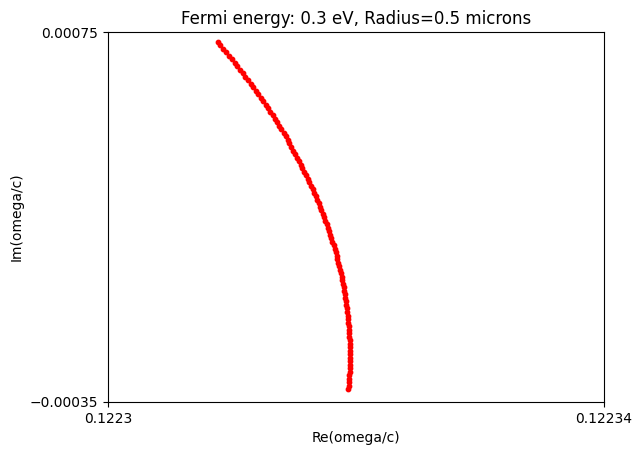

In [152]:
s = 10
plt.scatter(resonance_omegas_real, resonance_omegas_imag, color="red", s=s) 
plt.xlim(omega_over_c_real.min(), omega_over_c_real.max())
plt.ylim(omega_over_c_imag.min(), omega_over_c_imag.max());
plt.yticks([omega_over_c_imag.min(), omega_over_c_imag.max()])
plt.xticks([omega_over_c_real.min(), omega_over_c_real.max()], [omega_over_c_real.min(), omega_over_c_real.max()]);
plt.xlabel("Re(omega/c)")
plt.ylabel("Im(omega/c)")
plt.title(f"Fermi energy: {epsilon_F} eV, Radius={R} microns");

### We repeat the above calculation but for a Fermi energy of $0.7\text{eV}$.

In [40]:
epsilon_F = 0.7 # Fermi energy in eV
gamma = 1e-4 # Scattering rate in eV
epsilon = 4.9 # Permittivity of the bulk
R = 0.5 # Radius in microns
N_omega_over_c = 1000 # Number of sampled frequency points
omega_over_c_real = linspace(0.18618, 0.18621, N_omega_over_c) # Re(omega/c)
omega_over_c_real_reshaped = np.repeat(np.reshape(omega_over_c_real, (N_omega_over_c, 1)), N_omega_over_c, axis=1)
omega_over_c_imag = linspace(-5e-4, 1.2e-3, N_omega_over_c) # Im(omega/c)
omega_over_c_imag_reshaped = np.repeat(np.reshape(omega_over_c_imag, (1, N_omega_over_c)), N_omega_over_c, axis=0)
omega_over_c_mat = omega_over_c_real_reshaped + 1j* omega_over_c_imag_reshaped
sigmas_mat = graphene_conductivity(epsilon_F, (hbar*c/1000) * omega_over_c_mat, gamma, include_interband=False);

In [41]:
l = 1
N_epsilons = 100
epsilons_imag = linspace(-0.1, 0, N_epsilons)
resonance_omegas_real = zeros(N_epsilons)
resonance_omegas_imag = zeros(N_epsilons)
x_mat = R * omega_over_c_mat

resonance_minima = zeros(N_epsilons)
for (epsilon_imag_idx, epsilon_imag) in enumerate(epsilons_imag):
    resonances = h_z_cpa_denominator(l, x_mat, epsilon + 1j*epsilon_imag, -1j*sigmas_mat);
    resonance_minima[epsilon_imag_idx] = np.abs(resonances).min()
    resonance_omega = omega_over_c_mat.flatten()[np.abs(resonances).argmin()]
    resonance_omegas_real[epsilon_imag_idx] = resonance_omega.real
    resonance_omegas_imag[epsilon_imag_idx] = resonance_omega.imag

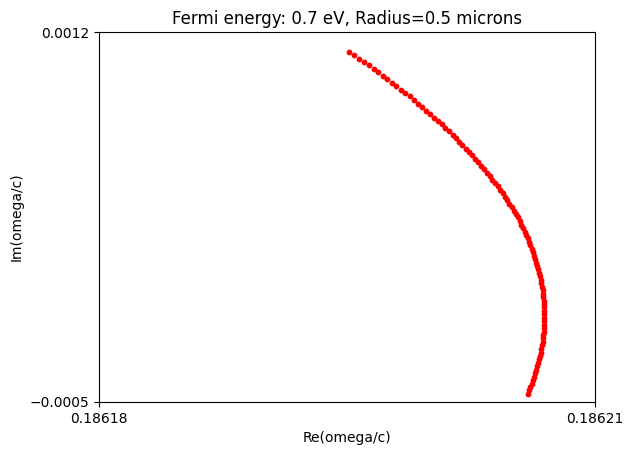

In [42]:
s = 10
plt.scatter(resonance_omegas_real, resonance_omegas_imag, color="red", s=s) 
plt.xlim(omega_over_c_real.min(), omega_over_c_real.max())
plt.ylim(omega_over_c_imag.min(), omega_over_c_imag.max());
plt.yticks([omega_over_c_imag.min(), omega_over_c_imag.max()])
plt.xticks([omega_over_c_real.min(), omega_over_c_real.max()], [omega_over_c_real.min(), omega_over_c_real.max()]);
plt.xlabel("Re(omega/c)")
plt.ylabel("Im(omega/c)")
plt.title(f"Fermi energy: {epsilon_F} eV, Radius={R} microns");

### Now we do the same calculations but with the effects of finite temperature taken into account. We follow the approximation made by **Equation 1** and **Equation 2** of the paper. However, note that both of these equations have typos. In particular, **Equation 1** has an extra factor of $\hbar$ in the denominator (which means it is dimensionally inconsistent). In addition, **Equation 2** is too large by a factor of $4$. For the correct formulation, please see **Equation 19**, **Equation 22** and **Equation 23** of the following paper: [Optical properties of graphene and IV ± VI semiconductors](https://iopscience.iop.org/article/10.1070/PU2008v051n09ABEH006625/pdf?casa_token=PI2Xma8kj24AAAAA:iqDZQqjqXkRZdtUmFIMZha6R-awlEk663OKztMOiWS4qPQg1byFAL0SnE4xsUWWzMQub6vWiKpuqcmoGhnVOb6kXVOU) by **Falkovsky**. 

In [77]:
def graphene_conductivity_finite_t(epsilon_F, hbar_omega, gamma, kT):
    sigma_intra = 8j*kT*alpha/(hbar_omega+1j*gamma)*log(2*cosh(epsilon_F/(2*kT)))
    sigma_inter_prefactor = pi*alpha
    sigma_inter_1 = sigma_inter_prefactor*(1/2+(1/pi)*atan((hbar_omega-2*epsilon_F)/(2*kT)))
    sigma_inter_2 = sigma_inter_prefactor*(-1j/(2*pi))*log((hbar_omega+2*epsilon_F)**2/((hbar_omega-2*epsilon_F)**2+(2*kT)**2))
    return sigma_intra + sigma_inter_1 + sigma_inter_2

In [78]:
epsilon_F = 0.3 # Fermi energy in eV
gamma = 1e-4 # Scattering rate in eV
epsilon = 4.9 # Permittivity of the bulk
R = 0.5 # Radius in microns
kT =  8.617333262e-5 * 300 # k_B * T for T = 300 Kelvin
N_omega_over_c = 1000 # Number of sampled frequency points
omega_over_c_real = linspace(0.122215, 0.122230, N_omega_over_c) # Re(omega/c)
omega_over_c_real_reshaped = np.repeat(np.reshape(omega_over_c_real, (N_omega_over_c, 1)), N_omega_over_c, axis=1)
omega_over_c_imag = linspace(-4.5e-4, 6.5e-4, N_omega_over_c) # Im(omega/c)
omega_over_c_imag_reshaped = np.repeat(np.reshape(omega_over_c_imag, (1, N_omega_over_c)), N_omega_over_c, axis=0)
omega_over_c_mat = omega_over_c_real_reshaped + 1j* omega_over_c_imag_reshaped
sigmas_mat = graphene_conductivity_finite_t(epsilon_F, (hbar*c/1000) * omega_over_c_mat, gamma, kT);

In [79]:
l = 1
N_epsilons = 100
epsilons_imag = linspace(-0.1, 0, N_epsilons)
resonance_omegas_real = zeros(N_epsilons)
resonance_omegas_imag = zeros(N_epsilons)
x_mat = R * omega_over_c_mat

for (epsilon_imag_idx, epsilon_imag) in enumerate(epsilons_imag):
    resonances = h_z_cpa_denominator(l, x_mat, epsilon + 1j*epsilon_imag, -1j*sigmas_mat);
    resonance_omega = omega_over_c_mat.flatten()[np.abs(resonances).argmin()]
    resonance_omegas_real[epsilon_imag_idx] = resonance_omega.real
    resonance_omegas_imag[epsilon_imag_idx] = resonance_omega.imag

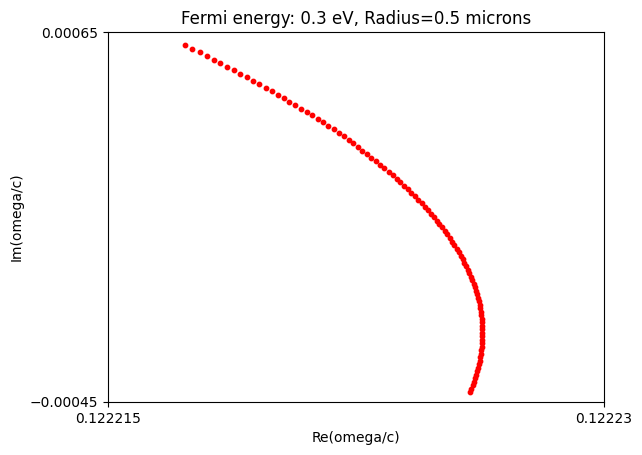

In [95]:
s = 10
plt.scatter(resonance_omegas_real, resonance_omegas_imag, color="red", s=s) 
plt.xlim(omega_over_c_real.min(), omega_over_c_real.max())
plt.ylim(omega_over_c_imag.min(), omega_over_c_imag.max());
plt.yticks([omega_over_c_imag.min(), omega_over_c_imag.max()])
plt.xticks([omega_over_c_real.min(), omega_over_c_real.max()], [omega_over_c_real.min(), omega_over_c_real.max()]);
plt.xlabel("Re(omega/c)")
plt.ylabel("Im(omega/c)")
plt.title(f"Fermi energy: {epsilon_F} eV, Radius={R} microns");

In [97]:
print("Imaginary part of frequency (Im(omega)/c) in units of inverse microns without gain: ", resonance_omegas_imag[-1])

Imaginary part of frequency (Im(omega)/c) in units of inverse microns without gain:  -0.00042247247247247246


In [129]:
epsilon_F = 0.7 # Fermi energy in eV
gamma = 1e-4 # Scattering rate in eV
epsilon = 4.9 # Permittivity of the bulk
R = 0.5 # Radius in microns
kT =  8.617333262e-5 * 300 # k_B * T for T = 300 Kelvin
N_omega_over_c = 1000 # Number of sampled frequency points
omega_over_c_real = linspace(0.1861, 0.1862, N_omega_over_c) # Re(omega/c)
omega_over_c_real_reshaped = np.repeat(np.reshape(omega_over_c_real, (N_omega_over_c, 1)), N_omega_over_c, axis=1)
omega_over_c_imag = linspace(-6e-4, 12e-4, N_omega_over_c) # Im(omega/c)
omega_over_c_imag_reshaped = np.repeat(np.reshape(omega_over_c_imag, (1, N_omega_over_c)), N_omega_over_c, axis=0)
omega_over_c_mat = omega_over_c_real_reshaped + 1j* omega_over_c_imag_reshaped
sigmas_mat = graphene_conductivity_finite_t(epsilon_F, (hbar*c/1000) * omega_over_c_mat, gamma, kT);

In [130]:
l = 1
N_epsilons = 100
epsilons_imag = linspace(-0.1, 0, N_epsilons)
resonance_omegas_real = zeros(N_epsilons)
resonance_omegas_imag = zeros(N_epsilons)
x_mat = R * omega_over_c_mat

for (epsilon_imag_idx, epsilon_imag) in enumerate(epsilons_imag):
    resonances = h_z_cpa_denominator(l, x_mat, epsilon + 1j*epsilon_imag, -1j*sigmas_mat);
    resonance_omega = omega_over_c_mat.flatten()[np.abs(resonances).argmin()]
    resonance_omegas_real[epsilon_imag_idx] = resonance_omega.real
    resonance_omegas_imag[epsilon_imag_idx] = resonance_omega.imag

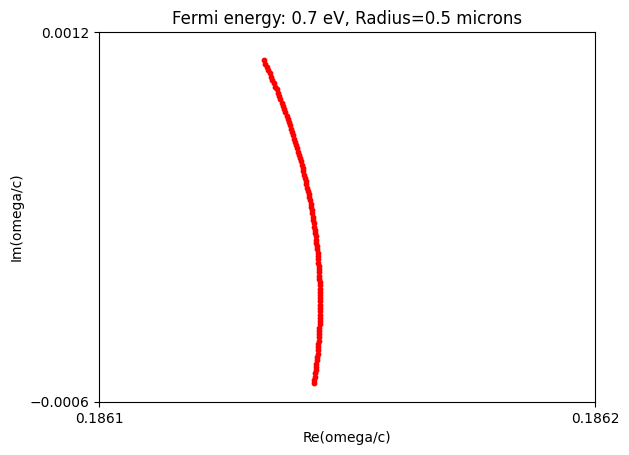

In [131]:
s = 10
plt.scatter(resonance_omegas_real, resonance_omegas_imag, color="red", s=s) 
plt.xlim(omega_over_c_real.min(), omega_over_c_real.max())
plt.ylim(omega_over_c_imag.min(), omega_over_c_imag.max());
plt.yticks([omega_over_c_imag.min(), omega_over_c_imag.max()])
plt.xticks([omega_over_c_real.min(), omega_over_c_real.max()], [omega_over_c_real.min(), omega_over_c_real.max()]);
plt.xlabel("Re(omega/c)")
plt.ylabel("Im(omega/c)")
plt.title(f"Fermi energy: {epsilon_F} eV, Radius={R} microns");

In [134]:
print("Imaginary part of frequency (Im(omega)/c) in units of inverse microns without gain: ", resonance_omegas_imag[-1])

Imaginary part of frequency (Im(omega)/c) in units of inverse microns without gain:  -0.0005099099099099098
